In [27]:
##Question:
#How does cold gas structure change across spatial scales around a GMC, and how does this relate to nearby star cluster formation?

## Approach:
#I visualized cold gas surface density across progressively smaller spatial windows centered on a single GMC in a FIRE-2 simulation (m12i), overlaying star cluster positions.

## Key Insight:
#Dense gas structure becomes increasingly coherent at smaller scales, and nearby star clusters appear preferentially aligned with higher-density regions, consistent with star formation occurring in locally overdense gas environments.

In [28]:
# Multiscale Cold Gas Structure Around a GMC

# This notebook visualizes the cold gas surface density surrounding a giant molecular cloud (GMC)
# in a Milky Way-like simulation (m12i).

# The figure presents progressively smaller spatial windows centered on the same GMC, with nearby
# star clusters overlaid. This multiscale view highlights how cold gas structure evolves from
# global galactic morphology to localized dense regions, and how young stellar clustering relates
# to these structures.

# All visualizations are generated using preprocessed simulation data products.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
from pathlib import Path
from scipy.ndimage import gaussian_filter
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from matplotlib.font_manager import FontProperties
from scipy.ndimage import maximum_filter

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14
})

In [30]:
# --- data / configuration ---
base = Path("data")

gface = np.load(base / "gface.npy")   # gas surface density map
sxc   = np.load(base / "sxc.npy")     # star cluster x positions [kpc]
syc   = np.load(base / "syc.npy")     # star cluster y positions [kpc]
smc   = np.load(base / "smc.npy")     # star cluster masses [Msun]

# GMC center (coordinates) [kpc]
gmc_x = 5.053701
gmc_y = 7.747334

# Replace with the true plotting extent if different
extent_kpc = (-25, 25, -25, 25)

# Progressive zoom window sizes [kpc]
zoom_sizes = [50.0, 5.0, 1.0, 0.5]

# Snapshot metadata
simulation_name = "m12i_res7100"
snapshot_number = 600
snapshot_time_gyr = 13.8

# Smoothed gas map used in final visualization
gface_s = gaussian_filter(gface, sigma=1.0)
img2d = gface_s

img2d = np.where(img2d < 0.05, np.nan, img2d)

# Plot styling
norm = LogNorm(vmin=1, vmax=3e4)
cmap = "RdYlBu_r"
xmin, xmax, ymin, ymax = extent_kpc

In [31]:
def window_limits(cx, cy, size):
    half_size = size / 2.0
    return cx - half_size, cx + half_size, cy - half_size, cy + half_size

In [32]:
def add_scale_bar(ax, length_kpc=5, label=None, loc="lower left", pad=0.35, color="black"):
    if label is None:
        label = f"{length_kpc:g} kpc"

    fontprops = FontProperties(size=11)
    loc_map = {
        "upper right": 1,
        "upper left": 2,
        "lower left": 3,
        "lower right": 4,
    }

    scalebar = AnchoredSizeBar(
        ax.transData,
        length_kpc,
        label,
        loc=loc_map[loc],
        pad=pad,
        color=color,
        frameon=False,
        size_vertical=0.0,
        fontproperties=fontprops,
    )
    ax.add_artist(scalebar)

Text(0.5, 1.02, 'Multiscale structure of cold gas around a GMC in m12i_res7100 (snapshot 600, t = 13.8 Gyr)')

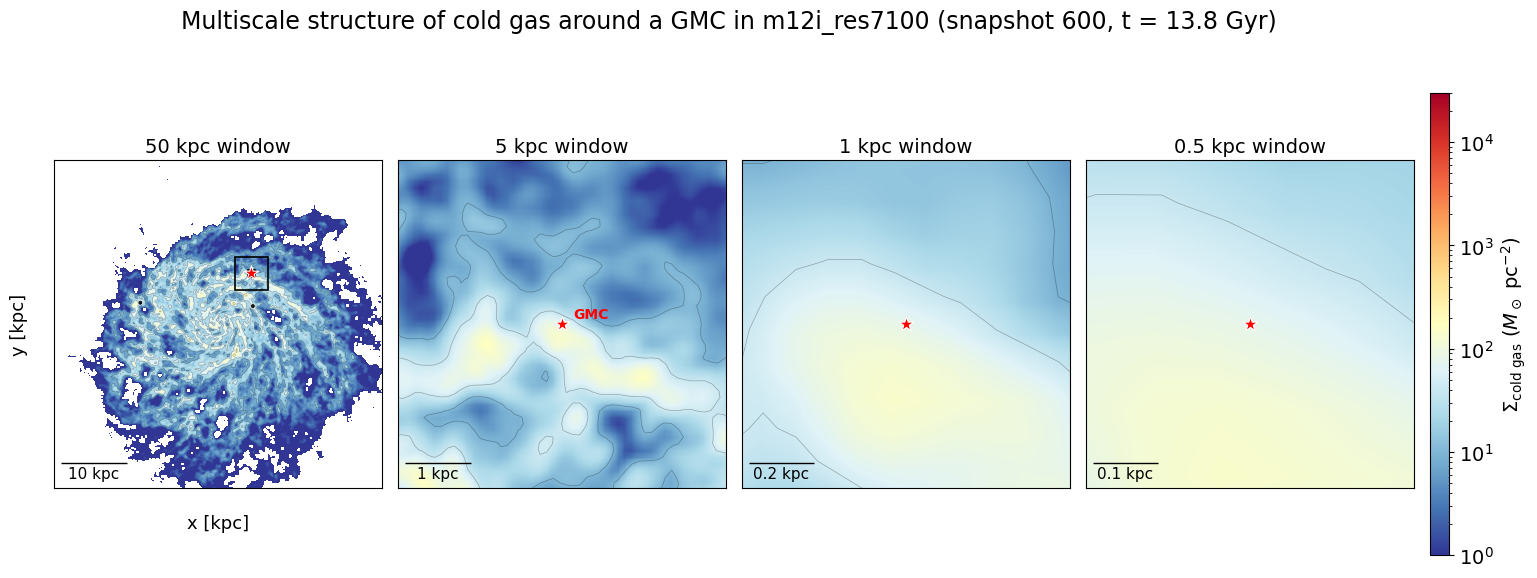

In [33]:
n = len(zoom_sizes)

fig = plt.figure(figsize=(18, 6))
gs = GridSpec(1, n + 1, width_ratios=[1] * n + [0.06], wspace=0.06, figure=fig)

axs = [fig.add_subplot(gs[0, i]) for i in range(n)]
cax = fig.add_subplot(gs[0, -1])

for i, size in enumerate(zoom_sizes):
    ax = axs[i]

    im = ax.imshow(
        img2d,
        origin="lower",
        extent=extent_kpc,
        norm=norm,
        cmap=cmap,
        interpolation="bilinear"
    )

    # --- density contours (FIXED INDENTATION) ---
    levels = np.logspace(1, 3.5, 5)

    ax.contour(
        img2d,
        levels=levels,
        colors='black',
        linewidths=0.5,
        alpha=0.3,
        extent=extent_kpc
    )

    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{size:g} kpc window", fontsize=14)

    if i == 0:
        x0w, x1w, y0w, y1w = xmin, xmax, ymin, ymax
        ax.set_xlim(x0w, x1w)
        ax.set_ylim(y0w, y1w)

        for s in zoom_sizes[1:]:
            xb0, xb1, yb0, yb1 = window_limits(gmc_x, gmc_y, s)
            rect = Rectangle(
                (xb0, yb0),
                xb1 - xb0,
                yb1 - yb0,
                fill=False,
                lw=1.2,
                ec="k"
            )
            ax.add_patch(rect)
    else:
        x0w, x1w, y0w, y1w = window_limits(gmc_x, gmc_y, size)
        ax.set_xlim(x0w, x1w)
        ax.set_ylim(y0w, y1w)

    in_panel = (
        (sxc >= x0w) & (sxc <= x1w) &
        (syc >= y0w) & (syc <= y1w)
    )

    marker_size = 10 + 2.0 * np.log10(np.clip(smc[in_panel], 1e4, None) / 1e4)

    ax.scatter(
        sxc[in_panel],
        syc[in_panel],
        s=marker_size,
        c="k",
        marker="o",
        edgecolors="white",
        linewidths=0.5,
        alpha=0.9,
        zorder=5,
    )

    ax.scatter(
        gmc_x, gmc_y,
        s=120,
        marker="*",
        color="red",
        edgecolors="white",
        linewidths=0.8,
        zorder=6,
    )

    if i == 1:
        ax.annotate(
            "GMC",
            xy=(gmc_x, gmc_y),
            xytext=(8, 4),
            textcoords="offset points",
            color="red",
            fontsize=10,
            weight="bold"
        )

axs[0].set_xlabel("x [kpc]", fontsize=13)
axs[0].set_ylabel("y [kpc]", fontsize=13)
axs[0].xaxis.set_label_coords(0.5, -0.08)
axs[0].yaxis.set_label_coords(-0.08, 0.5)

add_scale_bar(axs[0], length_kpc=10, loc="lower left")
add_scale_bar(axs[1], length_kpc=1, loc="lower left")
add_scale_bar(axs[2], length_kpc=0.2, loc="lower left", color="black")
add_scale_bar(axs[3], length_kpc=0.1, loc="lower left", color="black")

cb = fig.colorbar(im, cax=cax)
cb.set_label(r'$\Sigma_{\rm cold\ gas}\ (M_\odot\ \mathrm{pc}^{-2})$', fontsize=14)

fig.suptitle(
    f"Multiscale structure of cold gas around a GMC in {simulation_name} (snapshot {snapshot_number}, t = {snapshot_time_gyr:.1f} Gyr)",
    y=1.02,
    fontsize=17
)

In [34]:
def find_gmc_candidates(img2d, extent_kpc, min_separation_kpc=3.0, threshold_percentile=99.5):
    """
    Find candidate GMC centers as strong local maxima in the 2D cold-gas map.

    Returns a list of dictionaries with:
        x, y, value, ix, iy
    sorted from highest to lower peak value.
    """
    xmin, xmax, ymin, ymax = extent_kpc
    ny, nx = img2d.shape

    x_coords = np.linspace(xmin, xmax, nx)
    y_coords = np.linspace(ymin, ymax, ny)

    # approximate pixel scale in kpc
    dx = (xmax - xmin) / (nx - 1)
    dy = (ymax - ymin) / (ny - 1)
    pixel_scale = 0.5 * (dx + dy)

    # convert min separation into pixels
    min_sep_pix = max(1, int(min_separation_kpc / pixel_scale))

    # ignore NaNs for thresholding
    valid_vals = img2d[np.isfinite(img2d)]
    threshold = np.percentile(valid_vals, threshold_percentile)

    # local maxima detection
    local_max = maximum_filter(img2d, size=min_sep_pix, mode="nearest")
    peak_mask = (img2d == local_max) & (img2d >= threshold) & np.isfinite(img2d)

    iy_idx, ix_idx = np.where(peak_mask)

    candidates = []
    for iy, ix in zip(iy_idx, ix_idx):
        candidates.append({
            "x": x_coords[ix],
            "y": y_coords[iy],
            "value": img2d[iy, ix],
            "ix": ix,
            "iy": iy,
        })

    # sort by descending peak strength
    candidates = sorted(candidates, key=lambda d: d["value"], reverse=True)

    return candidates

In [35]:
# find candidate GMC centers from gas peaks
gmc_candidates = find_gmc_candidates(
    img2d,
    extent_kpc=extent_kpc,
    min_separation_kpc=3.0,
    threshold_percentile=99.5
)

print(f"Found {len(gmc_candidates)} candidate peaks.\n")

for i, c in enumerate(gmc_candidates[:10]):
    print(f"{i:2d}: x = {c['x']:.3f}, y = {c['y']:.3f}, peak = {c['value']:.3f}")

Found 33 candidate peaks.

 0: x = 4.217, y = 4.518, peak = 282.703
 1: x = 2.410, y = -4.719, peak = 271.094
 2: x = 2.410, y = 3.112, peak = 255.218
 3: x = -4.317, y = -2.410, peak = 222.960
 4: x = -8.835, y = 1.908, peak = 203.622
 5: x = -2.610, y = 4.719, peak = 186.479
 6: x = -9.337, y = -0.100, peak = 178.264
 7: x = -12.952, y = 2.811, peak = 177.611
 8: x = 9.137, y = 5.422, peak = 175.458
 9: x = 3.916, y = 7.430, peak = 172.460


In [36]:
def distance_kpc(x1, y1, x2, y2):
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

# existing GMC
gmc1_x = gmc_x
gmc1_y = gmc_y

# choose the strongest candidate far enough away from GMC 1
min_distance_from_gmc1 = 5.0  # kpc

gmc2 = None
for c in gmc_candidates:
    d = distance_kpc(gmc1_x, gmc1_y, c["x"], c["y"])
    if d >= min_distance_from_gmc1:
        gmc2 = c
        break

if gmc2 is None:
    raise ValueError("No suitable second GMC candidate found. Try lowering the threshold or separation.")

gmc2_x = gmc2["x"]
gmc2_y = gmc2["y"]

print(f"GMC 1: x = {gmc1_x:.3f}, y = {gmc1_y:.3f}")
print(f"GMC 2: x = {gmc2_x:.3f}, y = {gmc2_y:.3f}, peak = {gmc2['value']:.3f}")
print(f"Separation = {distance_kpc(gmc1_x, gmc1_y, gmc2_x, gmc2_y):.3f} kpc")

GMC 1: x = 5.054, y = 7.747
GMC 2: x = 2.410, y = -4.719, peak = 271.094
Separation = 12.744 kpc


In [37]:
gmc_catalog = {
    "GMC 1": {"x": gmc1_x, "y": gmc1_y},
    "GMC 2": {"x": gmc2_x, "y": gmc2_y},
}

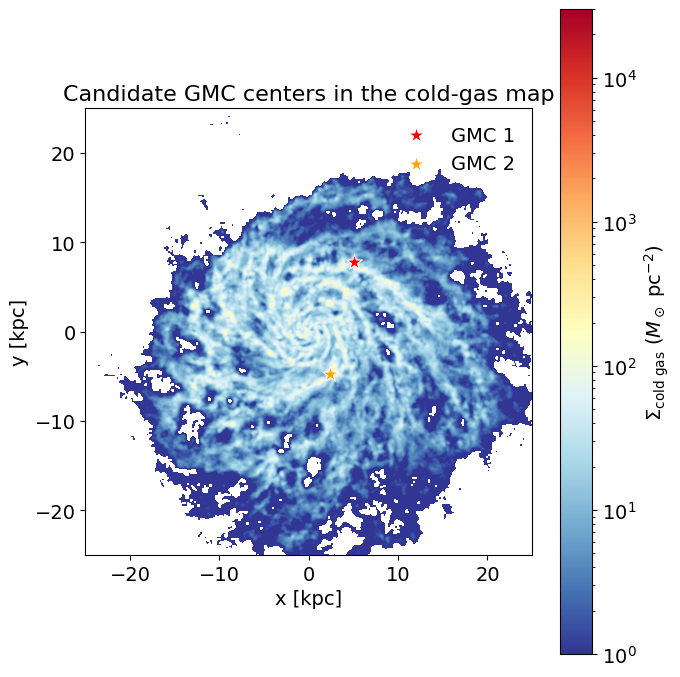

In [38]:
fig_check, ax = plt.subplots(figsize=(7, 7))

im = ax.imshow(
    img2d,
    origin="lower",
    extent=extent_kpc,
    norm=norm,
    cmap=cmap,
    interpolation="bilinear"
)

ax.scatter(gmc1_x, gmc1_y, s=140, marker="*", color="red", edgecolors="white", linewidths=0.8, label="GMC 1")
ax.scatter(gmc2_x, gmc2_y, s=140, marker="*", color="orange", edgecolors="white", linewidths=0.8, label="GMC 2")

ax.set_xlabel("x [kpc]")
ax.set_ylabel("y [kpc]")
ax.set_title("Candidate GMC centers in the cold-gas map")
ax.legend(frameon=False)

cb = fig_check.colorbar(im, ax=ax)
cb.set_label(r'$\Sigma_{\rm cold\ gas}\ (M_\odot\ \mathrm{pc}^{-2})$')

fig_check.tight_layout()
plt.show()
plt.close(fig_check)

In [39]:
def compute_density_scale_metrics(img2d, gmc_x, gmc_y, zoom_sizes, xmin, xmax, ymin, ymax):
    """
    Compute mean cold gas surface density within progressively smaller
    spatial windows centered on a GMC.
    """

    results = []

    for size in zoom_sizes:
        half = size / 2.0

        x0, x1 = gmc_x - half, gmc_x + half
        y0, y1 = gmc_y - half, gmc_y + half

        # convert physical coords → pixel indices
        nx, ny = img2d.shape

        x = np.linspace(xmin, xmax, nx)
        y = np.linspace(ymin, ymax, ny)

        X, Y = np.meshgrid(x, y, indexing='ij')

        mask = (X >= x0) & (X <= x1) & (Y >= y0) & (Y <= y1)

        values = img2d[mask]

        # remove NaNs (important since you masked low-density regions)
        values = values[~np.isnan(values)]

        if len(values) == 0:
            mean_density = np.nan
        else:
            mean_density = np.mean(values)

        results.append(mean_density)

    return np.array(results)

In [40]:
def compute_density_scale_metrics(img2d, gmc_x, gmc_y, zoom_sizes, xmin, xmax, ymin, ymax):
    """
    Compute mean, median, and 90th-percentile cold gas surface density
    within progressively smaller spatial windows centered on a GMC.
    """

    mean_vals = []
    median_vals = []
    p90_vals = []

    for size in zoom_sizes:
        half = size / 2.0

        x0, x1 = gmc_x - half, gmc_x + half
        y0, y1 = gmc_y - half, gmc_y + half

        ny, nx = img2d.shape
        x = np.linspace(xmin, xmax, nx)
        y = np.linspace(ymin, ymax, ny)

        X, Y = np.meshgrid(x, y, indexing="xy")

        mask = (X >= x0) & (X <= x1) & (Y >= y0) & (Y <= y1)

        values = img2d[mask]
        values = values[np.isfinite(values)]

        if len(values) == 0:
            mean_vals.append(np.nan)
            median_vals.append(np.nan)
            p90_vals.append(np.nan)
        else:
            mean_vals.append(np.mean(values))
            median_vals.append(np.median(values))
            p90_vals.append(np.percentile(values, 90))

    return {
        "mean": np.array(mean_vals),
        "median": np.array(median_vals),
        "p90": np.array(p90_vals),
    }

In [41]:
comparison_results = {}

for gmc_name, gmc_info in gmc_catalog.items():
    comparison_results[gmc_name] = compute_density_scale_metrics(
        img2d=img2d,
        gmc_x=gmc_info["x"],
        gmc_y=gmc_info["y"],
        zoom_sizes=zoom_sizes,
        xmin=xmin,
        xmax=xmax,
        ymin=ymin,
        ymax=ymax,
    )

In [42]:
print(type(comparison_results))
for name, result in comparison_results.items():
    print(name, type(result), result.keys() if isinstance(result, dict) else "NOT A DICT")

<class 'dict'>
GMC 1 <class 'dict'> dict_keys(['mean', 'median', 'p90'])
GMC 2 <class 'dict'> dict_keys(['mean', 'median', 'p90'])


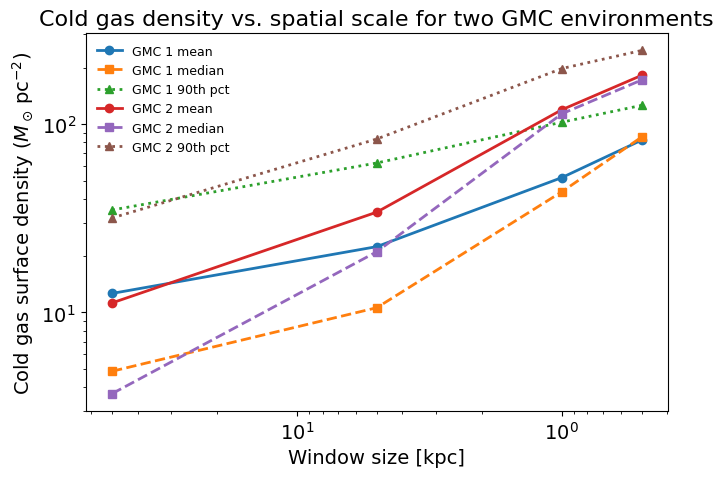

In [43]:
fig_compare, ax = plt.subplots(figsize=(7, 5))

for gmc_name, result in comparison_results.items():
    ax.plot(zoom_sizes, result["mean"], marker="o", linewidth=2, label=f"{gmc_name} mean")
    ax.plot(zoom_sizes, result["median"], marker="s", linewidth=2, linestyle="--", label=f"{gmc_name} median")
    ax.plot(zoom_sizes, result["p90"], marker="^", linewidth=2, linestyle=":", label=f"{gmc_name} 90th pct")

ax.set_xscale("log")
ax.invert_xaxis()
ax.set_yscale("log")

ax.set_xlabel("Window size [kpc]")
ax.set_ylabel(r"Cold gas surface density $(M_\odot\,\mathrm{pc}^{-2})$")
ax.set_title("Cold gas density vs. spatial scale for two GMC environments")
ax.legend(frameon=False, fontsize=9)

fig_compare.tight_layout()

outdir = Path("figures")
outdir.mkdir(parents=True, exist_ok=True)

fig_compare.savefig(outdir / "gmc_density_vs_scale_comparison.png", dpi=300, bbox_inches="tight")
fig_compare.savefig(outdir / "gmc_density_vs_scale_comparison.pdf", bbox_inches="tight")

plt.show()
plt.close(fig_compare)

In [44]:
## GMC Selection Note

# The first GMC center was selected from the existing analysis workflow. 
# A second comparison region was identified by locating a strong local maximum in the 2D cold-gas surface density map, subject to a minimum spatial separation from the first GMC. 
# This provides a clean comparison target, while remaining distinct from a full GMC catalog generated with a dedicated cloud-finding algorithm.

In [45]:
def plot_multiscale_gmc(img2d, gmc_x, gmc_y, title_suffix=""):
    
    n = len(zoom_sizes)

    fig = plt.figure(figsize=(18, 6))
    gs = GridSpec(1, n + 1, width_ratios=[1] * n + [0.06], wspace=0.06, figure=fig)

    axs = [fig.add_subplot(gs[0, i]) for i in range(n)]
    cax = fig.add_subplot(gs[0, -1])

    for i, size in enumerate(zoom_sizes):
        ax = axs[i]

        im = ax.imshow(
            img2d,
            origin="lower",
            extent=extent_kpc,
            norm=norm,
            cmap=cmap,
            interpolation="bilinear"
        )

        # --- contours ---
        levels = np.logspace(1, 3.5, 5)
        ax.contour(
            img2d,
            levels=levels,
            colors='black',
            linewidths=0.5,
            alpha=0.6,
            extent=extent_kpc
        )

        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"{size:g} kpc window", fontsize=14)

        if i == 0:
            x0w, x1w, y0w, y1w = xmin, xmax, ymin, ymax
            ax.set_xlim(x0w, x1w)
            ax.set_ylim(y0w, y1w)

            for s in zoom_sizes[1:]:
                xb0, xb1, yb0, yb1 = window_limits(gmc_x, gmc_y, s)
                rect = Rectangle(
                    (xb0, yb0),
                    xb1 - xb0,
                    yb1 - yb0,
                    fill=False,
                    lw=1.2,
                    ec="k"
                )
                ax.add_patch(rect)
        else:
            x0w, x1w, y0w, y1w = window_limits(gmc_x, gmc_y, size)
            ax.set_xlim(x0w, x1w)
            ax.set_ylim(y0w, y1w)

        # star clusters
        in_panel = (
            (sxc >= x0w) & (sxc <= x1w) &
            (syc >= y0w) & (syc <= y1w)
        )

        marker_size = 10 + 2.0 * np.log10(np.clip(smc[in_panel], 1e4, None) / 1e4)

        ax.scatter(
            sxc[in_panel],
            syc[in_panel],
            s=marker_size,
            c="k",
            edgecolors="white",
            linewidths=0.5,
            alpha=0.9,
            zorder=5,
        )

        # GMC marker
        ax.scatter(
            gmc_x, gmc_y,
            s=120,
            marker="*",
            color="red",
            edgecolors="white",
            linewidths=0.8,
            zorder=6,
        )

        if i == 1:
            ax.annotate(
                "GMC",
                xy=(gmc_x, gmc_y),
                xytext=(8, 4),
                textcoords="offset points",
                color="red",
                fontsize=10,
                weight="bold"
            )

    # scale bars
    add_scale_bar(axs[0], length_kpc=10)
    add_scale_bar(axs[1], length_kpc=1)
    add_scale_bar(axs[2], length_kpc=0.2)
    add_scale_bar(axs[3], length_kpc=0.1)

    cb = fig.colorbar(im, cax=cax)
    cb.set_label(r'$\Sigma_{\rm cold\ gas}\ (M_\odot\ \mathrm{pc}^{-2})$', fontsize=14)

    fig.suptitle(
        f"Multiscale structure around GMC {title_suffix}",
        fontsize=17,
        y=1.02
    )

    fig.subplots_adjust(wspace=0.05, right=0.88)
    return fig

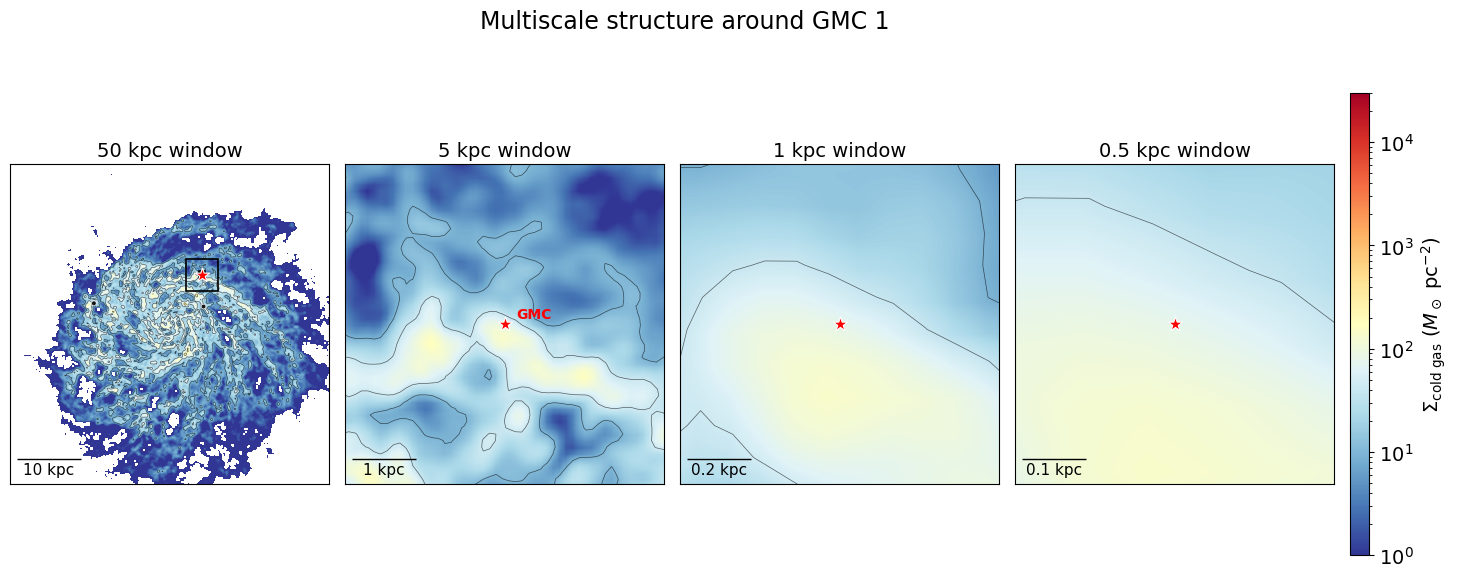

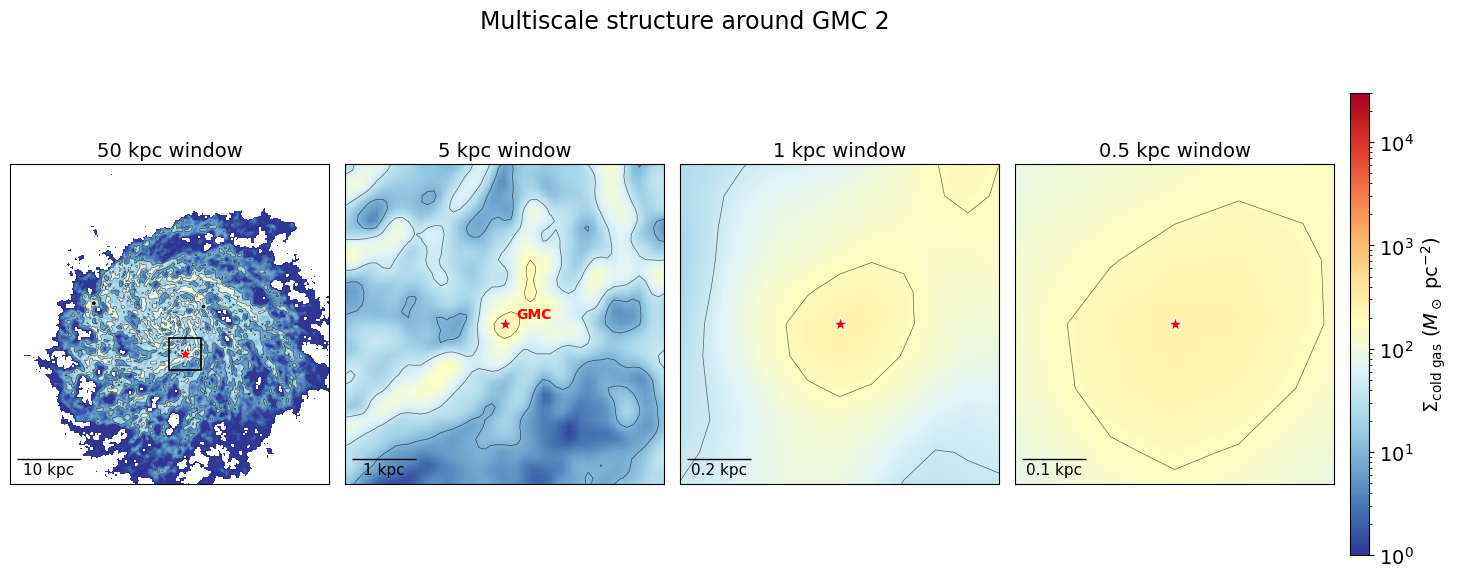

In [46]:
fig1 = plot_multiscale_gmc(img2d, gmc_x, gmc_y, title_suffix="1")
fig2 = plot_multiscale_gmc(img2d, gmc2_x, gmc2_y, title_suffix="2")

outdir = Path("figures")
outdir.mkdir(parents=True, exist_ok=True)

fig1.savefig(outdir / "gmc1_multiscale.png", dpi=300, bbox_inches="tight")
fig2.savefig(outdir / "gmc2_multiscale.png", dpi=300, bbox_inches="tight")

plt.show()

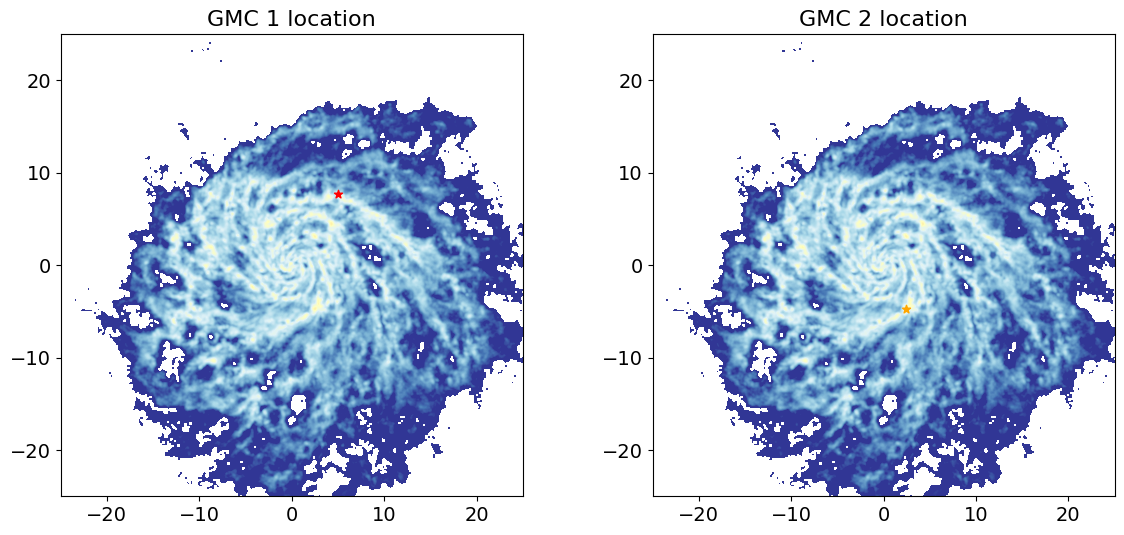

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left: GMC1 global
axes[0].imshow(img2d, origin="lower", extent=extent_kpc, norm=norm, cmap=cmap)
axes[0].scatter(gmc_x, gmc_y, color="red", marker="*")
axes[0].set_title("GMC 1 location")

# right: GMC2 global
axes[1].imshow(img2d, origin="lower", extent=extent_kpc, norm=norm, cmap=cmap)
axes[1].scatter(gmc2_x, gmc2_y, color="orange", marker="*")
axes[1].set_title("GMC 2 location")

plt.show()

In [48]:
# --- quantitative metric: mean density vs spatial scale ---

# build coordinate arrays for the image grid
ny, nx = img2d.shape
x_coords = np.linspace(xmin, xmax, nx)
y_coords = np.linspace(ymin, ymax, ny)
X, Y = np.meshgrid(x_coords, y_coords)

mean_densities = []
median_densities = []
p90_densities = []

for size in zoom_sizes:
    x0, x1, y0, y1 = window_limits(gmc_x, gmc_y, size)

    mask = (X >= x0) & (X <= x1) & (Y >= y0) & (Y <= y1)
    vals = img2d[mask]
    vals = vals[np.isfinite(vals)]  # remove NaNs if you masked low-density background

    mean_densities.append(np.mean(vals))
    median_densities.append(np.median(vals))
    p90_densities.append(np.percentile(vals, 90))

mean_densities = np.array(mean_densities)
median_densities = np.array(median_densities)
p90_densities = np.array(p90_densities)

# display values
for size, m, med, p90 in zip(zoom_sizes, mean_densities, median_densities, p90_densities):
    print(f"{size:>5g} kpc window  |  mean = {m:8.3f}  |  median = {med:8.3f}  |  p90 = {p90:8.3f}")

   50 kpc window  |  mean =   12.612  |  median =    4.864  |  p90 =   35.016
    5 kpc window  |  mean =   22.362  |  median =   10.589  |  p90 =   62.248
    1 kpc window  |  mean =   52.050  |  median =   43.758  |  p90 =  102.553
  0.5 kpc window  |  mean =   82.279  |  median =   85.407  |  p90 =  125.999


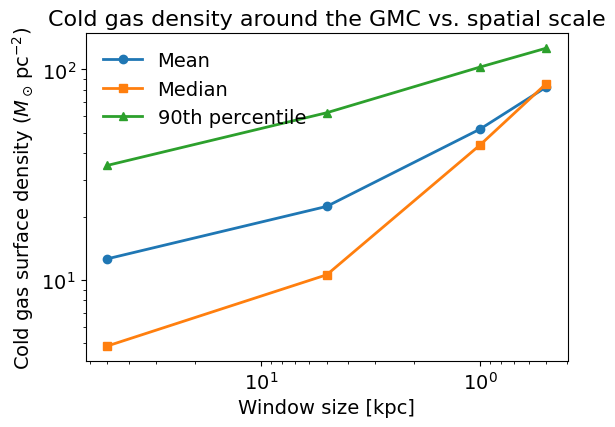

In [49]:
# --- plot mean density vs scale ---

fig_metric, ax = plt.subplots(figsize=(6, 4.5))

ax.plot(zoom_sizes, mean_densities, marker="o", linewidth=2, label="Mean")
ax.plot(zoom_sizes, median_densities, marker="s", linewidth=2, label="Median")
ax.plot(zoom_sizes, p90_densities, marker="^", linewidth=2, label="90th percentile")

ax.set_xscale("log")
ax.invert_xaxis()  # large scale on left, small scale on right
ax.set_yscale("log")

ax.set_xlabel("Window size [kpc]")
ax.set_ylabel(r"Cold gas surface density $(M_\odot\,\mathrm{pc}^{-2})$")
ax.set_title("Cold gas density around the GMC vs. spatial scale")
ax.legend(frameon=False)

fig_metric.tight_layout()

outdir = Path("figures")
outdir.mkdir(parents=True, exist_ok=True)

fig_metric.savefig(outdir / "gmc_density_vs_scale.png", dpi=300, bbox_inches="tight")
fig_metric.savefig(outdir / "gmc_density_vs_scale.pdf", bbox_inches="tight")

plt.show()
plt.close(fig_metric)

In [50]:
## Quantitative Follow-up

#To complement the multiscale visualization, the mean, median, and 90th-percentile cold-gas surface densities were measured in square windows centered on the same GMC. This provides a simple quantitative check on how the local gas environment changes as the spatial scale decreases.

#An increase in the characteristic density toward smaller windows would support the interpretation that the GMC is embedded in a locally enhanced dense-gas region rather than being selected from a uniform background.

In [51]:
outdir = Path("figures")
outdir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    outdir / "multiscale_gmc_density.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    outdir / "multiscale_gmc_density.pdf",
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

In [52]:
## Interpretation

# The two GMC environments exhibit distinct scaling behavior in cold gas surface density.
# GMC 2 shows systematically higher mean and upper-percentile densities at all spatial scales,
# indicating a more centrally concentrated or actively star-forming environment.

# The divergence between mean and 90th percentile values suggests that high-density substructure
# becomes increasingly dominant at smaller scales, consistent with hierarchical gas fragmentation.

# In contrast, GMC 1 exhibits a flatter scaling relation, implying a more diffuse or less evolved
# gas distribution.

# These differences demonstrate that GMC environments are not uniform, and that local density structure
# plays a key role in regulating star formation efficiency.